# 3. Evolution: which strategies survive?

**Goal.** Move from a tournament (a fixed list of players) to a **population** whose composition changes: strategies that score well reproduce, the others disappear. We use two models:

- the **Moran process**: a small population, random births and deaths (stochastic);
- the **ecosystem**: the shares of each strategy evolve in proportion to their tournament scores (deterministic, close to the replicator dynamics seen with nashpy).

In [ ]:
#if axelrod is not installed on colab, install it with
#!pip install axelrod

In [ ]:
# !!!! ONLY ON COLAB !!!!
import sys
import os
from google.colab import drive

#give access to your personal Google Drive (check the authorization, ...)
drive.mount('/content/drive')


# 2. Add the exact path where you put the jupyter books and myNashTools.py
# (Example : if it is in folder the "Colab Notebooks/Axelrod-Book" on your Drive)
my_folder = '/content/drive/MyDrive/Colab Notebooks/Axelrod-Book'
if my_folder not in sys.path:
    sys.path.insert(0, my_folder)


if os.path.exists(my_folder):
    print(f"✅ the folder exists !")
    fichiers = os.listdir(my_folder)
    print("Content of the folder :", fichiers)
    
    # On force l'insertion au tout début du path
    if my_folder not in sys.path:
        sys.path.insert(0, my_folder)
        
else:
    print(f"❌ folder does not exist at this path. Verify the spelling or the space.")


In [1]:
import axelrod as axl
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from myIGTools import show_game, print_ranking

pd = axl.Game()                                  # prisoner's dilemma (R=3, S=0, T=5, P=1)
stag = axl.Game(r=4, s=0, t=3, p=3)              # stag hunt
chicken = axl.Game(r=3, s=1, t=5, p=0)           # chicken

## 3.1 The Moran process

At each step:
1. every individual plays a match against every other one (`turns` turns); its **fitness** is its total score;
2. one individual is chosen to **reproduce**, with a probability proportional to its fitness: it is copied;
3. one individual, chosen uniformly at random, **dies** and is replaced by the copy.

The process stops when a single strategy remains (**fixation**).

winner: Grudger after 219 steps


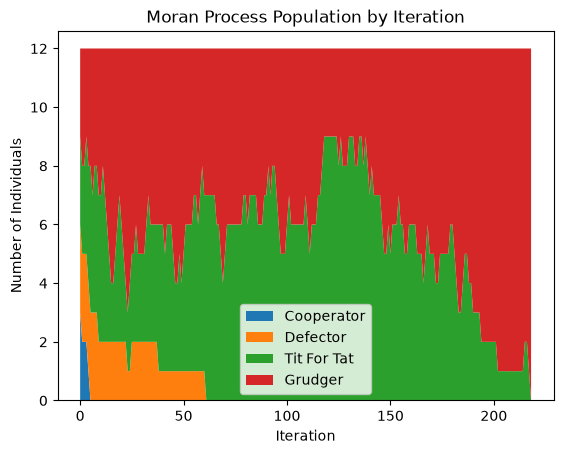

In [5]:
population = [axl.Cooperator(), axl.Defector(), axl.TitForTat(), axl.Grudger()] * 3
mp = axl.MoranProcess(population, turns=50, game=pd, seed=0)
populations = mp.play()
print("winner:", mp.winning_strategy_name, "after", len(populations), "steps")
mp.populations_plot()
plt.show()

**Reading.** 
- Cooperator is eliminated first: it is exploited by Defector. 
- Then Defector disappears as well: it only gets $P=1$ against the reactive strategies, which get $R=3$ among themselves. 
- Once Defector is gone, Cooperator, Tit For Tat and Grudger all cooperate and get exactly the same score: from then on, the winner is decided by **chance** alone (*neutral drift*).



----

**Question 1** *(≈ 6 lines)*. 
- Run the same Moran process with 20 different seeds (`seed=0` … `seed=19`) and 
- count how many times each strategy wins, using `Counter`. 
- Does Defector often win? Is Cooperator always eliminated?

*Hint:* `Counter(["a", "b", "a"])` → `Counter({'a': 2, 'b': 1})`.

In [6]:
# Question 1: your code here

Counter({'Grudger': 8, 'Cooperator': 5, 'Tit For Tat': 4, 'Defector': 3})


Generally, Defector rarely wins; Cooperator wins about a quarter of the runs, **without** being a good strategy: it survives because the reactive strategies have eliminated the defectors for it.   
Evolution does not select "the best" strategy, only one that does well **in the current population**.

---

**Question 2** *(≈ 10 lines, with a plot)*. 
- In a population of 10 individuals, start with `k` Tit For Tat and `10 - k` Defector, for `k` in `[1, 3, 5, 7, 9]`. 
- For each `k`, run 10 Moran processes (seeds 0 to 9, `turns=50`) and compute the proportion of runs won by Tit For Tat. 
- Plot this **fixation probability** against `k`, together with the dashed line `k / 10`, which is what pure chance (neutral drift) would give.

In [8]:
# Exercise 2: your code here

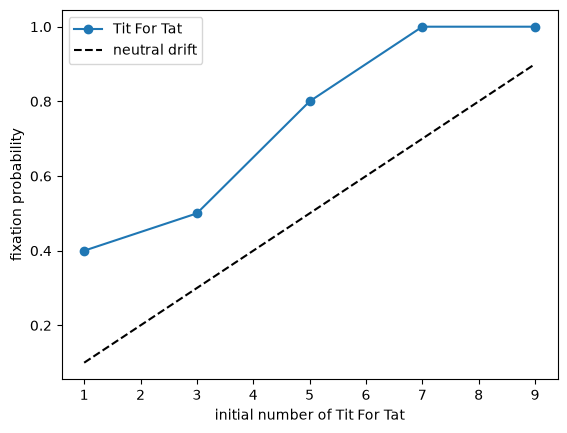

The curve is well above the dashed line: even a **single** Tit For Tat among 9 Defector takes over the population in a large share of the runs.   Two Tit For Tat that meet earn $3 \times 50$ each, while two Defector earn only $1 \times 50$: with long enough matches, a small group of reciprocators can invade a population of defectors.

----

**Question 3** *(≈ 7 lines)*. 
- Start from 5 Cooperator and 5 Defector. 
- For each game (`pd`, `stag`, `chicken`), run 20 Moran processes (seeds 0 to 19, `turns=50`) and count the winners. 
- In which game does Cooperator have a chance?

In [10]:
# Exercise 3: your code here

Prisoner's dilemma   Counter({'Defector': 20})
Stag hunt            Counter({'Defector': 15, 'Cooperator': 5})
Chicken              Counter({'Defector': 18, 'Cooperator': 2})


- **Prisoner's dilemma**: Defector always wins; defection is a dominant strategy, and Cooperator cannot retaliate.
- **Stag hunt**: Cooperator wins sometimes.  
Cooperators meeting each other earn $R=4$, more than anybody else, but a cooperator meeting a defector gets 0: the outcome depends on luck in the first steps.
- **Chicken**: Defector usually wins in such a small population, even though a population of defectors earns $P=0$ per turn: evolution can lead a population to a collectively bad outcome.

----

## 3.2 The ecosystem

`axl.Ecosystem` starts from the results of a tournament.  
All strategies start with the same share of the population; at each generation, the share of a strategy grows if its mean score against the **current** population is above average. There is no randomness here.

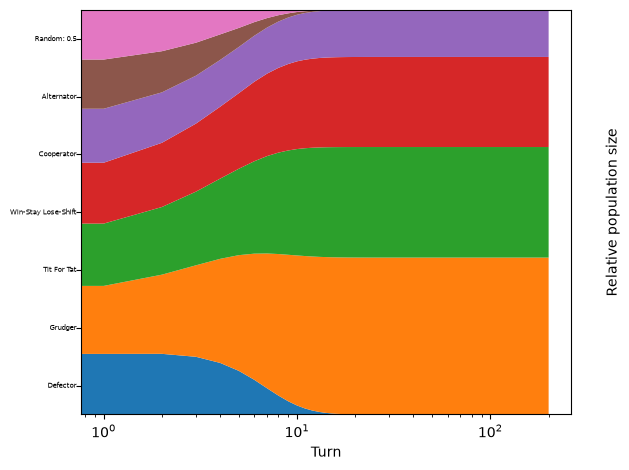

In [12]:
def make_players():
    return [axl.Cooperator(), axl.Defector(), axl.TitForTat(), axl.Grudger(),
            axl.WinStayLoseShift(), axl.Alternator(), axl.Random()]

results = axl.Tournament(make_players(), turns=100, repetitions=5, game=pd, seed=1).play(progress_bar=False)
eco = axl.Ecosystem(results)
eco.reproduce(200)                       # 200 generations
axl.Plot(results).stackplot(eco)
plt.show()

**Reading.** 
- Defector won this tournament (book 2), yet it **disappears** from the ecosystem within a few generations: its favourite victims (Alternator, Random) vanish and the nice strategies grow, so it has fewer and fewer players to exploit. 
- The survivors are the strategies that cooperate with each other: Grudger, Tit For Tat, Win-Stay Lose-Shift... and Cooperator, which is protected once Defector is gone. 
- Winning a tournament once is not the same as surviving in the long run.

---

**Exercise 4** *(≈ 5 lines)*. 
- Build the ecosystem of **Axelrod's first tournament** (`axl.axelrod_first_strategies`, `turns=200, repetitions=3, seed=1`) for 300 generations and draw its stackplot. 
- Then print the final share of each strategy, using `eco.population_sizes[-1]` (same order as `results.players`). 
- Which strategies die out?

In [10]:
# Exercise 4: your code here

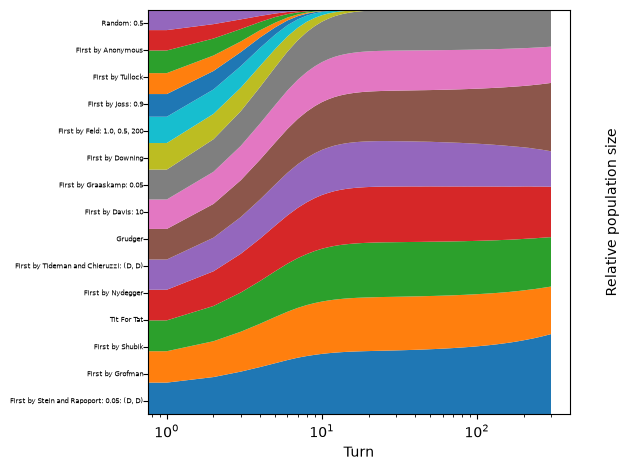

Tit For Tat                                12.5%
First by Tideman and Chieruzzi: (D, D)     16.9%
First by Nydegger                           8.8%
First by Grofman                           11.7%
First by Shubik                            12.2%
First by Stein and Rapoport: 0.05: (D, D)  19.9%
Grudger                                     9.0%
First by Davis: 10                          9.1%
First by Graaskamp: 0.05                    0.0%
First by Downing                            0.0%
First by Feld: 1.0, 0.5, 200                0.0%
First by Joss: 0.9                          0.0%
First by Tullock                            0.0%
First by Anonymous                          0.0%
Random: 0.5                                 0.0%


- The strategies that are never the first to defect (Tit For Tat, Grudger, Davis, Grofman, ...) share the population at the end; 
- the exploiting or erratic ones (Joss, Tullock, Anonymous, Random, ...) disappear. 
- This is the conclusion Axelrod drew in *The Evolution of Cooperation* (1984): **nice, retaliating, forgiving and clear** strategies are those that survive.

----

## Summary

| To… | write |
|---|---|
| run a Moran process | `mp = axl.MoranProcess(players, turns=…, game=…, seed=…)` then `mp.play()` |
| get the winner / plot it | `mp.winning_strategy_name`, `mp.populations_plot()` |
| build an ecosystem | `eco = axl.Ecosystem(results)` then `eco.reproduce(n)` |
| plot / read it | `axl.Plot(results).stackplot(eco)`, `eco.population_sizes[-1]` |